In [5]:
import torch
import torchvision

print("Torch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ Running on CPU")

Torch Version: 2.5.1
Torchvision Version: 0.20.1
Device: cuda
GPU: NVIDIA RTX A4000


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

# ===== YOUR PATHS =====
train_val_dir = r"F:\CV Project\LC25000\lung_colon_image_set\Train and Validation Set"
test_dir      = r"F:\CV Project\LC25000\lung_colon_image_set\Test Set"

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

In [7]:
TARGET_CLASSES = ['colon_aca', 'colon_n']

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

In [9]:
class FilteredImageFolder(Dataset):
    def __init__(self, root_dir, classes, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir)
        self.transform = transform
        
        # ✅ Ensure consistent ordering
        self.classes = sorted(classes)
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        
        self.samples = []

        for path, label in self.dataset.samples:
            class_name = self.dataset.classes[label]
            if class_name in self.classes:
                self.samples.append((path, self.class_to_idx[class_name]))

        print(f"✅ Total filtered samples: {len(self.samples)}")
        print(f"✅ Class mapping: {self.class_to_idx}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        
        try:
            image = Image.open(path).convert("RGB")
        except:
            # ⚠️ Handle corrupted image
            image = Image.new("RGB", (224, 224))

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
full_dataset = FilteredImageFolder(
    root_dir=train_val_dir,
    classes=TARGET_CLASSES,
    transform=train_transform
)

print("Classes:", full_dataset.classes)
print("Total colon Images:", len(full_dataset))

# Train-Val Split (80-20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size]
)

# Fix validation transform (NO augmentation)
val_dataset.dataset.transform = val_test_transform

✅ Total filtered samples: 9000
✅ Class mapping: {'colon_aca': 0, 'colon_n': 1}
Classes: ['colon_aca', 'colon_n']
Total colon Images: 9000


In [12]:
test_dataset = FilteredImageFolder(
    root_dir=test_dir,
    classes=TARGET_CLASSES,
    transform=val_test_transform
)

✅ Total filtered samples: 1000
✅ Class mapping: {'colon_aca': 0, 'colon_n': 1}


In [14]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = TARGET_CLASSES

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 7200
Val: 1800
Test: 1000


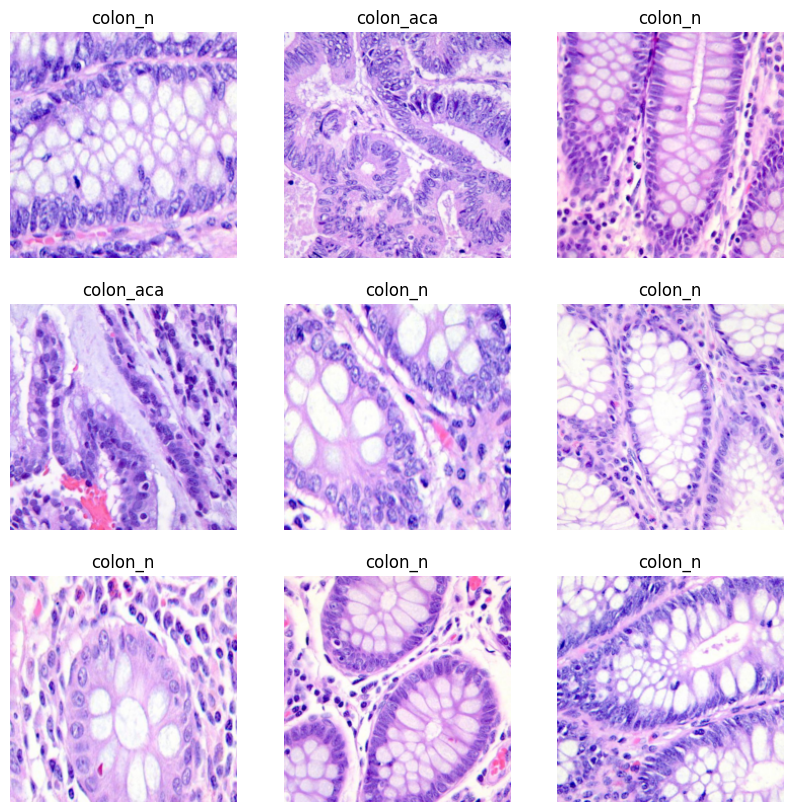

In [15]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    img = images[i].permute(1,2,0)
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

In [16]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Bramha/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:00<00:00, 57.3MB/s]


In [17]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

In [18]:
def train_model(model, train_loader, val_loader, epochs=25):
    best_acc = 0
    patience = 5
    counter = 0

    train_accs, val_accs = [], []
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # 🔁 TRAINING
        model.train()
        correct = 0
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / len(train_loader.dataset)

        # 🔍 VALIDATION
        model.eval()
        val_correct = 0
        val_running_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        # 📊 Store metrics
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # 🖨️ Print nicely
        print(f"Epoch {epoch+1}: "
              f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        # 📉 Scheduler
        scheduler.step(val_acc)

        # 🛑 Early stopping
        if val_acc > best_acc:
            best_acc = val_acc
            counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered")
            break

    return train_accs, val_accs, train_losses, val_losses

In [20]:
train_accs, val_accs, train_losses, val_losses = train_model(
    model, train_loader, val_loader, epochs=30
)

Epoch 1: Train Loss=0.2890, Train Acc=0.9681 | Val Loss=0.2297, Val Acc=0.9956
Epoch 2: Train Loss=0.2449, Train Acc=0.9885 | Val Loss=0.2194, Val Acc=0.9989
Epoch 3: Train Loss=0.2349, Train Acc=0.9921 | Val Loss=0.2183, Val Acc=0.9989
Epoch 4: Train Loss=0.2373, Train Acc=0.9899 | Val Loss=0.2202, Val Acc=0.9989
Epoch 5: Train Loss=0.2308, Train Acc=0.9921 | Val Loss=0.2140, Val Acc=0.9994
Epoch 6: Train Loss=0.2261, Train Acc=0.9960 | Val Loss=0.2125, Val Acc=0.9994
Epoch 7: Train Loss=0.2282, Train Acc=0.9943 | Val Loss=0.2137, Val Acc=0.9989
Epoch 8: Train Loss=0.2250, Train Acc=0.9957 | Val Loss=0.2109, Val Acc=0.9994
Epoch 9: Train Loss=0.2213, Train Acc=0.9976 | Val Loss=0.2109, Val Acc=0.9989
Epoch 10: Train Loss=0.2229, Train Acc=0.9965 | Val Loss=0.2118, Val Acc=0.9994
Early stopping triggered


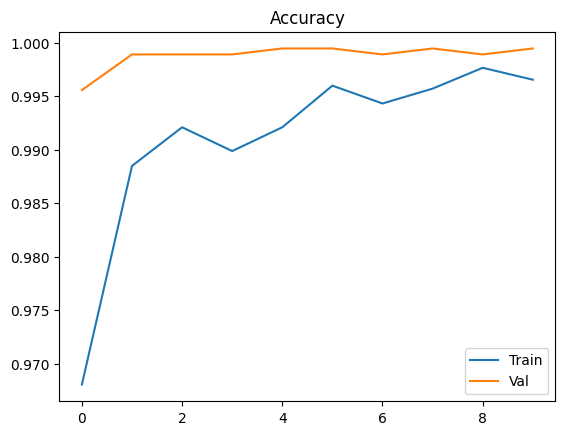

In [21]:
plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Val')
plt.legend()
plt.title("Accuracy")
plt.show()

In [22]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

C:\Users\Bramha\AppData\Local\Temp\ipykernel_9356\1639261356.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


              precision    recall  f1-score   support

   colon_aca       0.99      1.00      1.00       500
     colon_n       1.00      0.99      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



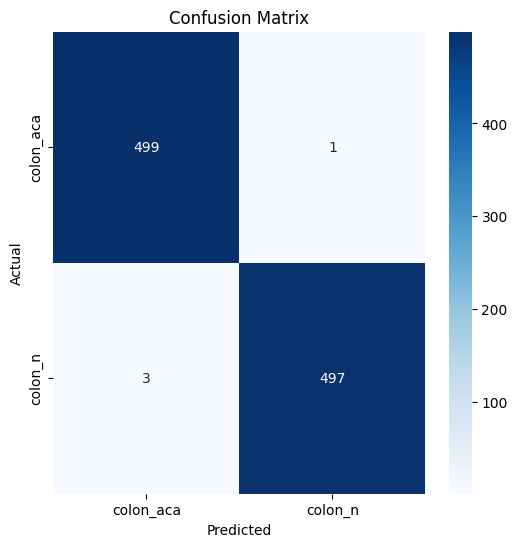

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
------------------TESTING---------------------------

In [28]:
import torchvision.transforms as transforms

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [29]:
classes = ['colon_aca', 'colon_n']

In [33]:
TARGET_CLASSES = ['colon_aca', 'colon_n']

test_dataset = FilteredImageFolder(
    test_dir,
    classes,   # ✅ FIXED
    transform=val_transform
)

✅ Total filtered samples: 1000
✅ Class mapping: {'colon_aca': 0, 'colon_n': 1}


In [34]:
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [35]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

C:\Users\Bramha\AppData\Local\Temp\ipykernel_9356\3738422358.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [36]:
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

In [37]:
from sklearn.metrics import classification_report

class_names = ['Colon_Adenocarcinoma', 'Colon_Normal']

print("\n📊 Test Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


📊 Test Classification Report:
                      precision    recall  f1-score   support

Colon_Adenocarcinoma       0.51      0.43      0.47       500
        Colon_Normal       0.51      0.59      0.54       500

            accuracy                           0.51      1000
           macro avg       0.51      0.51      0.51      1000
        weighted avg       0.51      0.51      0.51      1000



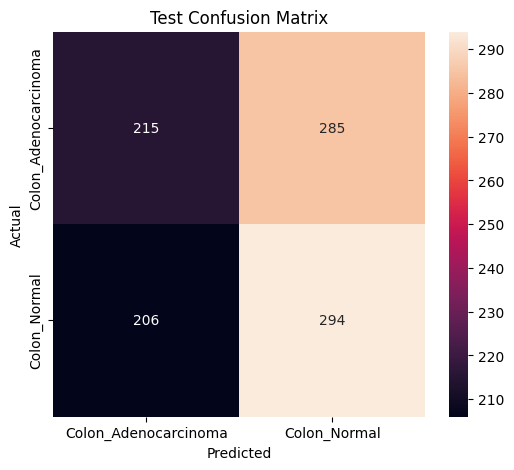

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Confusion Matrix")
plt.show()